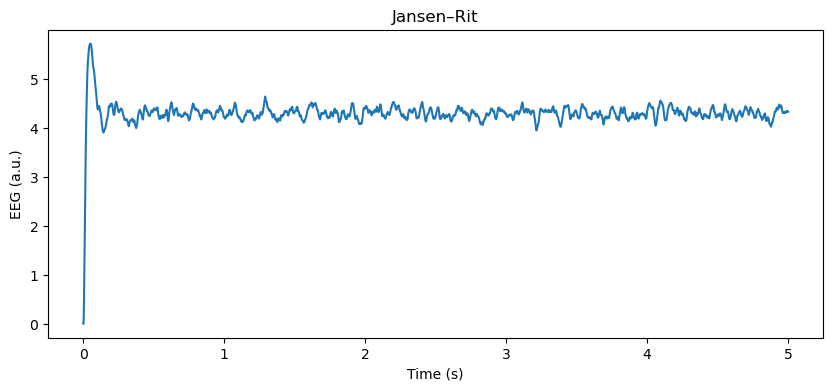

In [4]:
import numpy as np
import matplotlib.pyplot as plt


dt = 0.001
T  = 5.0
N  = int(T / dt)
time = np.arange(0, T, dt)


def sigmoid(v):
    e0 = 2.5
    v0 = 6.0
    r  = 0.56
    return (2*e0) / (1 + np.exp(r*(v0 - v)))


A = 3.25
B = 22.0
a = 100.0
b = 50.0

C2 = 108.0
C4 = 33.75

p = 220 + 20*np.random.randn(N)


y_e  = np.zeros(N); z_e  = np.zeros(N)
y_i  = np.zeros(N); z_i  = np.zeros(N)
y_pe = np.zeros(N); z_pe = np.zeros(N)
y_pi = np.zeros(N); z_pi = np.zeros(N)

v_p  = np.zeros(N)


for i in range(N-1):

    v_p[i] = y_pe[i] - y_pi[i]

    r_p = sigmoid(v_p[i])
    r_e = sigmoid(y_e[i])
    r_i = sigmoid(y_i[i])

    # Excitatory interneuron
    y_e[i+1] = y_e[i] + dt*z_e[i]
    z_e[i+1] = z_e[i] + dt*(A*a*r_p - 2*a*z_e[i] - a*a*y_e[i])

    # Inhibitory interneuron
    y_i[i+1] = y_i[i] + dt*z_i[i]
    z_i[i+1] = z_i[i] + dt*(B*b*r_p - 2*b*z_i[i] - b*b*y_i[i])

    # Pyramidal excitatory
    y_pe[i+1] = y_pe[i] + dt*z_pe[i]
    z_pe[i+1] = z_pe[i] + dt*(A*a*(p[i] + C2*r_e) - 2*a*z_pe[i] - a*a*y_pe[i])

    # Pyramidal inhibitory
    y_pi[i+1] = y_pi[i] + dt*z_pi[i]
    z_pi[i+1] = z_pi[i] + dt*(B*b*(C4*r_i) - 2*b*z_pi[i] - b*b*y_pi[i])

EEG = y_pe - y_pi

plt.figure(figsize=(10,4))
plt.plot(time, EEG)
plt.title("Jansen–Rit")
plt.xlabel("Time (s)")
plt.ylabel("EEG (a.u.)")
plt.show()


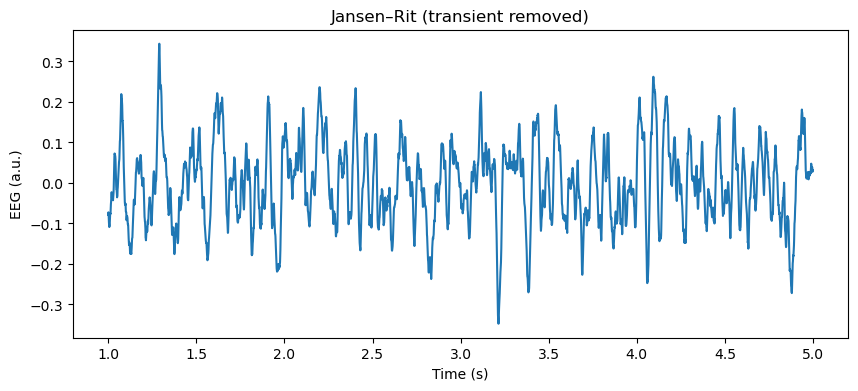

In [5]:
start = int(1.0 / dt)

EEG2 = EEG[start:]
EEG2 = EEG2 - np.mean(EEG2)

time2 = time[start:]

plt.figure(figsize=(10,4))
plt.plot(time2, EEG2)
plt.xlabel("Time (s)")
plt.ylabel("EEG (a.u.)")
plt.title("Jansen–Rit (transient removed)")
plt.show()


In [7]:
import numpy as np
import matplotlib.pyplot as plt


dt = 0.001
T  = 5.0
N  = int(T / dt)
time = np.arange(0, T, dt)
cut = int(1.0 / dt)   


def simulate(A, B, a, b, C2, C4, p):

    y_e  = np.zeros(N); z_e  = np.zeros(N)
    y_i  = np.zeros(N); z_i  = np.zeros(N)
    y_pe = np.zeros(N); z_pe = np.zeros(N)
    y_pi = np.zeros(N); z_pi = np.zeros(N)

    v_p = np.zeros(N)

    for i in range(N-1):

        v_p[i] = y_pe[i] - y_pi[i]

        r_p = sigmoid(v_p[i])
        r_e = sigmoid(y_e[i])
        r_i = sigmoid(y_i[i])

        # Excitatory interneuron
        y_e[i+1] = y_e[i] + dt*z_e[i]
        z_e[i+1] = z_e[i] + dt*(A*a*r_p - 2*a*z_e[i] - a*a*y_e[i])

        # Inhibitory interneuron
        y_i[i+1] = y_i[i] + dt*z_i[i]
        z_i[i+1] = z_i[i] + dt*(B*b*r_p - 2*b*z_i[i] - b*b*y_i[i])

        # Pyramidal excitatory
        y_pe[i+1] = y_pe[i] + dt*z_pe[i]
        z_pe[i+1] = z_pe[i] + dt*(A*a*(p[i] + C2*r_e) - 2*a*z_pe[i] - a*a*y_pe[i])

        # Pyramidal inhibitory
        y_pi[i+1] = y_pi[i] + dt*z_pi[i]
        z_pi[i+1] = z_pi[i] + dt*(B*b*(C4*r_i) - 2*b*z_pi[i] - b*b*y_pi[i])

    EEG = y_pe - y_pi
    EEG = EEG[cut:] - np.mean(EEG[cut:])
    t2  = time[cut:]

    return t2, EEG


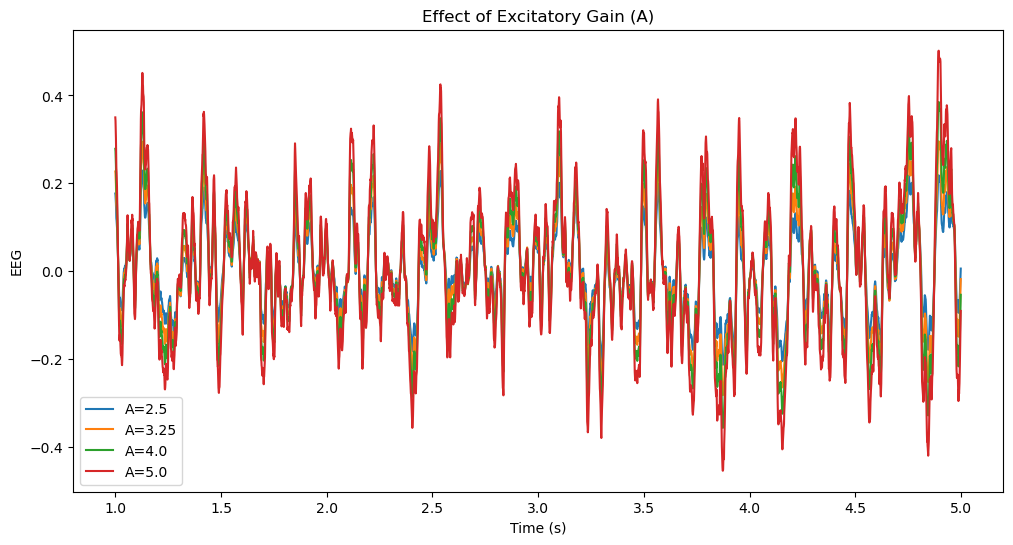

In [8]:
A_vals = [2.5, 3.25, 4.0, 5.0]

B = 22
a = 100; b = 50
C2 = 108; C4 = 33.75
p = 220 + 20*np.random.randn(N)

plt.figure(figsize=(12,6))

for A in A_vals:
    t2, EEG = simulate(A, B, a, b, C2, C4, p)
    plt.plot(t2, EEG, label=f"A={A}")

plt.legend()
plt.title("Effect of Excitatory Gain (A)")
plt.xlabel("Time (s)")
plt.ylabel("EEG")
plt.show()



We dont see Regular period  Constant amplitude  Phase locking in this graph
 
Therefore: This is **not** a limit-cycle oscillation.

However, this does not mean: The model is not working.

This is a noise-driven subcritical regime.  
As $A$ increases, the amplitude seems to increase; think of $A$ as an amplifier.  
It is not an oscillator (yet).

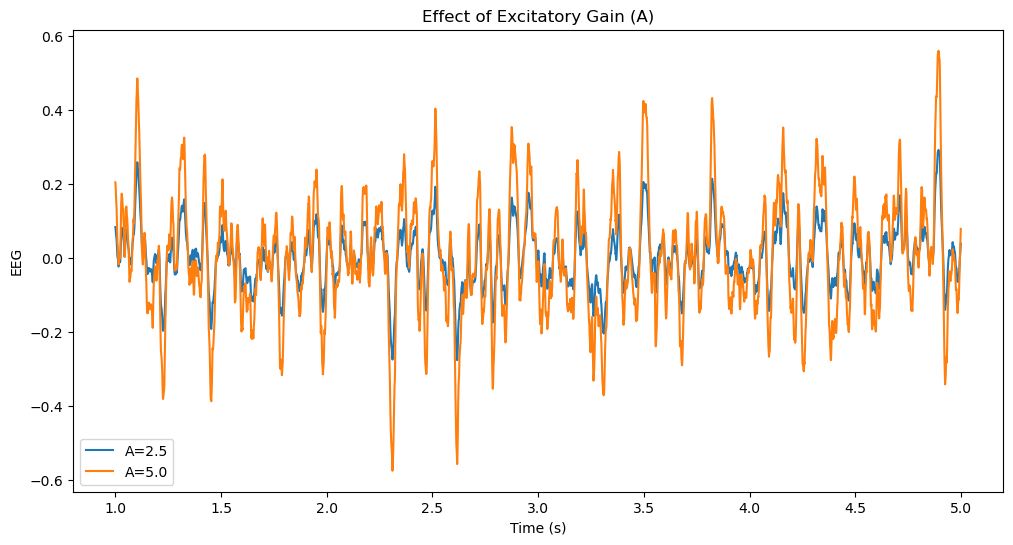

In [10]:
#to see it more clearly lets reduce A_vals to 2 value
A_vals = [2.5, 5.0]

B = 22
a = 100; b = 50
C2 = 108; C4 = 33.75
p = 220 + 20*np.random.randn(N)

plt.figure(figsize=(12,6))

for A in A_vals:
    t2, EEG = simulate(A, B, a, b, C2, C4, p)
    plt.plot(t2, EEG, label=f"A={A}")

plt.legend()
plt.title("Effect of Excitatory Gain (A)")
plt.xlabel("Time (s)")
plt.ylabel("EEG")
plt.show()

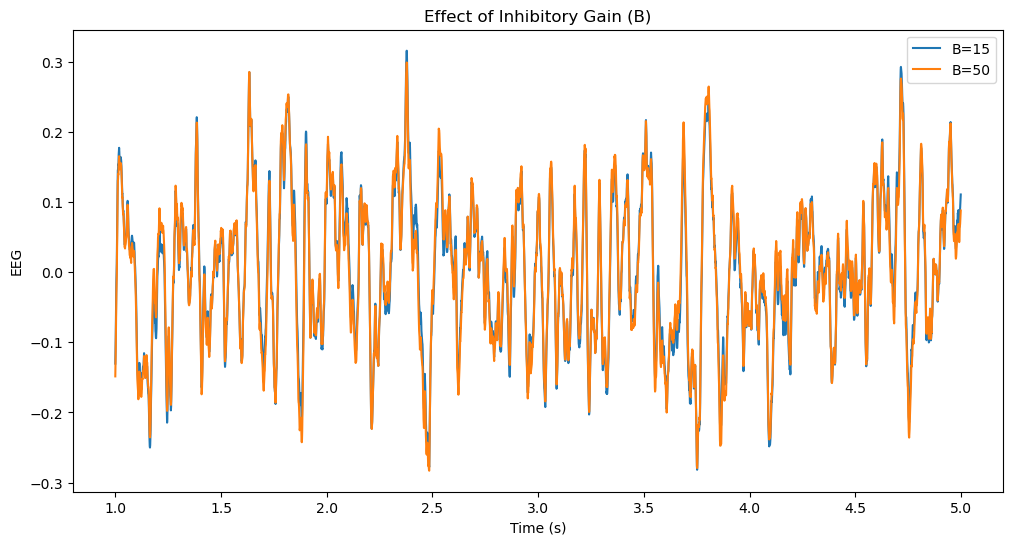

In [11]:
B_vals = [15, 50]

A = 3.25
a = 100; b = 50
C2 = 108; C4 = 33.75
p = 220 + 20*np.random.randn(N)

plt.figure(figsize=(12,6))

for B in B_vals:
    t2, EEG = simulate(A, B, a, b, C2, C4, p)
    plt.plot(t2, EEG, label=f"B={B}")

plt.legend()
plt.title("Effect of Inhibitory Gain (B)")
plt.xlabel("Time (s)")
plt.ylabel("EEG")
plt.show()


Why does increasing $B$ make it look like “nothing is happening”? 

Because right now the system is:Noise-drivenSubcritical 

Not gain-dominant, but balance-dominant (equilibrium-dominant)

In this regime:$A$ → “How much am I amplifying/boosting?”

$B$ → “How much am I damping/braking?”But:The damping is already very strong The system is already not an oscillator Therefore:Tightening the brake a little moredoesn’t create any dramatic differencein a car that’s already standing still.


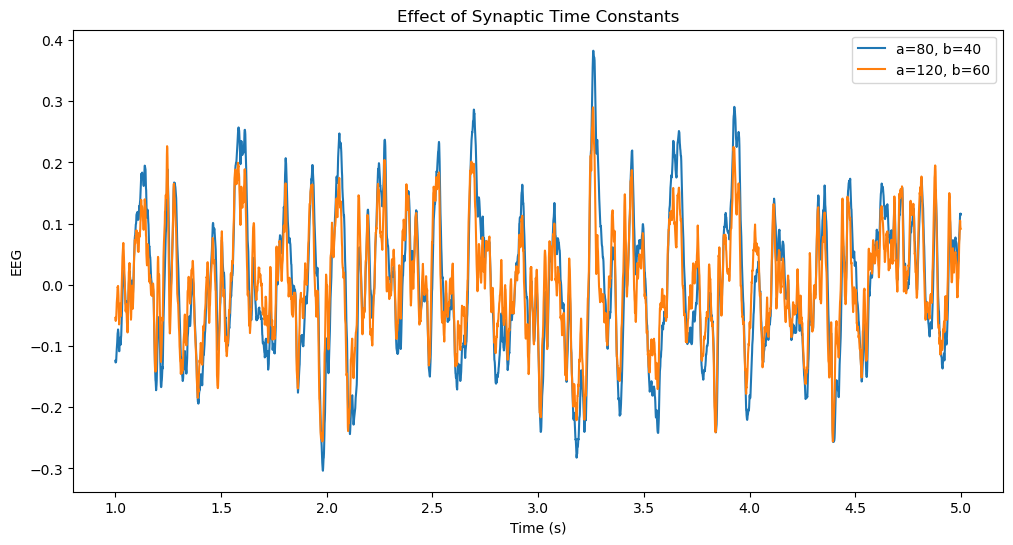

In [12]:
pairs = [(80,40),(120,60)]

A = 3.25
B = 22
C2 = 108; C4 = 33.75
p = 220 + 20*np.random.randn(N)

plt.figure(figsize=(12,6))

for a,b in pairs:
    t2, EEG = simulate(A, B, a, b, C2, C4, p)
    plt.plot(t2, EEG, label=f"a={a}, b={b}")

plt.legend()
plt.title("Effect of Synaptic Time Constants")
plt.xlabel("Time (s)")
plt.ylabel("EEG")
plt.show()


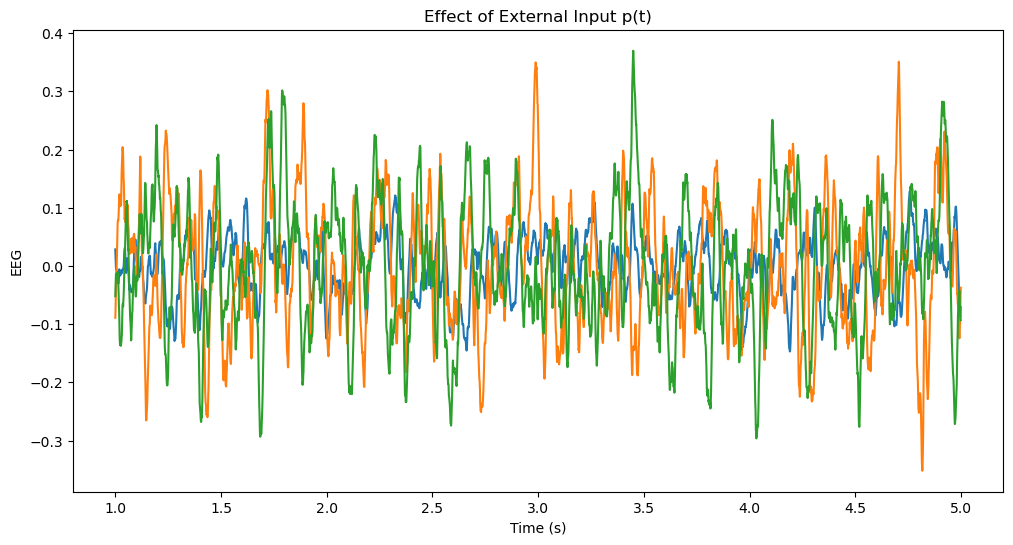

In [13]:
p_levels = [
    180 + 10*np.random.randn(N),
    220 + 20*np.random.randn(N),
    260 + 20*np.random.randn(N)
]

A = 3.25
B = 22
a = 100; b = 50
C2 = 108; C4 = 33.75

plt.figure(figsize=(12,6))

for p in p_levels:
    t2, EEG = simulate(A, B, a, b, C2, C4, p)
    plt.plot(t2, EEG)

plt.title("Effect of External Input p(t)")
plt.xlabel("Time (s)")
plt.ylabel("EEG")
plt.show()


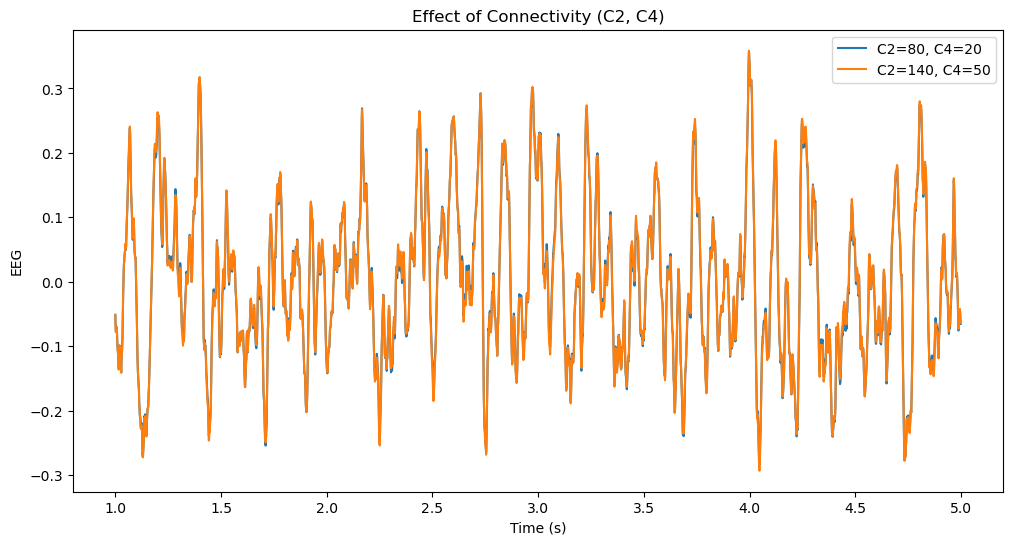

In [14]:
C2_vals = [80, 140]
C4_vals = [20, 50]

A = 3.25
B = 22
a = 100; b = 50
p = 220 + 20*np.random.randn(N)

plt.figure(figsize=(12,6))

for C2, C4 in zip(C2_vals, C4_vals):
    t2, EEG = simulate(A, B, a, b, C2, C4, p)
    plt.plot(t2, EEG, label=f"C2={C2}, C4={C4}")

plt.legend()
plt.title("Effect of Connectivity (C2, C4)")
plt.xlabel("Time (s)")
plt.ylabel("EEG")
plt.show()


In [15]:
from scipy.signal import welch

fs = 1 / dt  # sampling frequency (Hz)

freqs, psd = welch(
    EEG2,
    fs=fs,
    nperseg=2048
)


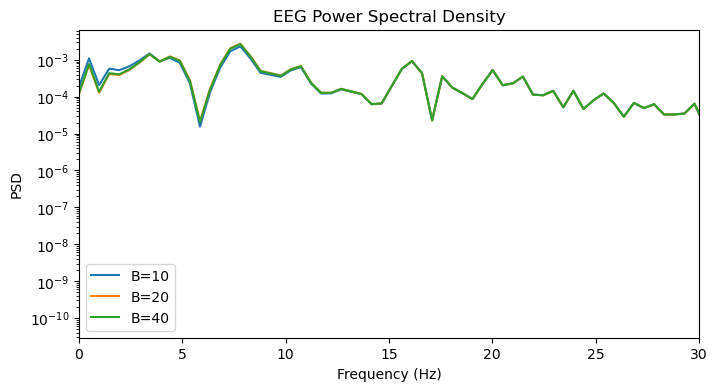

In [16]:
B_vals = [10, 20, 40]
fs = 1 / dt  # sampling frequency

plt.figure(figsize=(8,4))

for B in B_vals:
    t2, EEG = simulate(A, B, a, b, C2, C4, p)

    freqs, psd = welch(
        EEG,
        fs=fs,
        nperseg=2048
    )

    plt.semilogy(freqs, psd, label=f"B={B}")

plt.xlim(0, 30)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("EEG Power Spectral Density")
plt.legend()
plt.show()

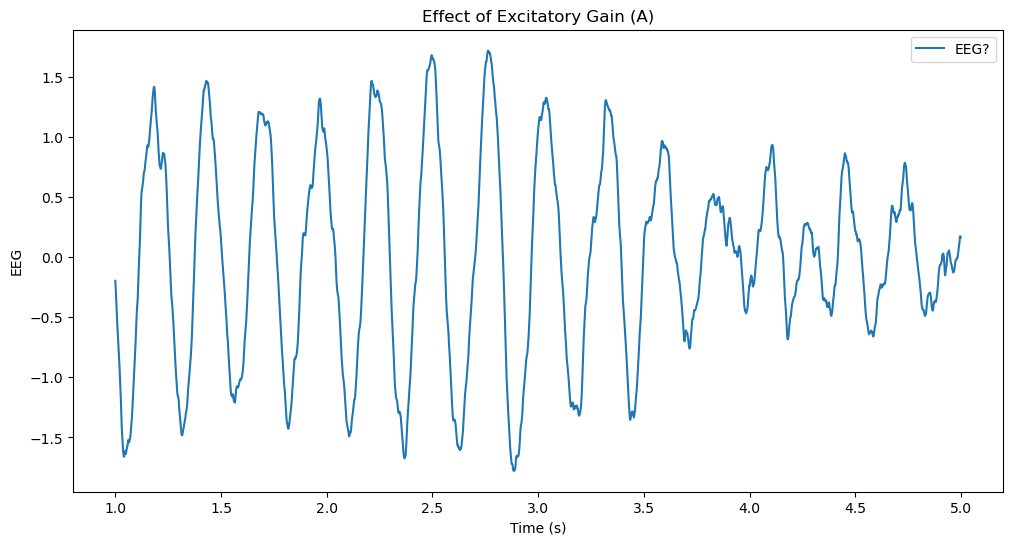

In [17]:
A=6
B = 22
a = 50; b = 25
C2 = 108; C4 = 33.75
p = 120 + 20*np.random.randn(N)

plt.figure(figsize=(12,6))


t2, EEG = simulate(A, B, a, b, C2, C4, p)
plt.plot(t2, EEG, label="EEG?")

plt.legend()
plt.title("Effect of Excitatory Gain (A)")
plt.xlabel("Time (s)")
plt.ylabel("EEG")
plt.show()

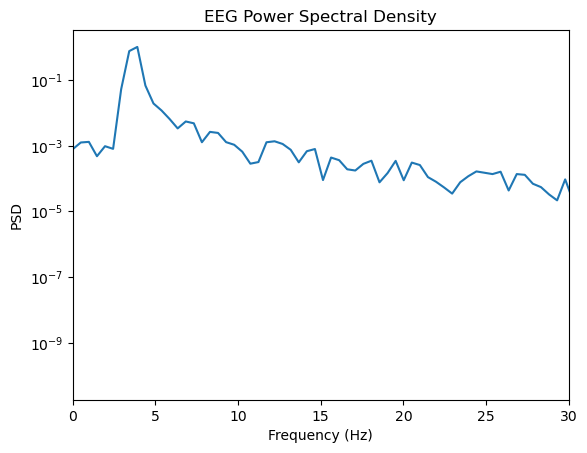

In [18]:
freqs, psd = welch(
        EEG,
        fs=fs,
        nperseg=2048
    )

plt.semilogy(freqs, psd)

plt.xlim(0, 30)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("EEG Power Spectral Density")
plt.show()

**When A = 6 → strong excitatory feedback**  
**a, b low → slow PSP → low frequency**  
**p moderate → noise that triggers oscillation without overwhelming it**  
**B moderate → doesn't kill the oscillation, but controls it**

In this configuration:

- High **A** provides powerful excitatory recurrent feedback (like turning up the gain)  
- Low **a** and **b** mean slow postsynaptic decay → oscillations at **lower frequencies**  
- Moderate **p** introduces just the right amount of noise to push the system across the threshold and initiate bursts, without making it chaotic  
- Moderate **B** damps the activity enough to prevent runaway growth, but not so much that everything dies out

**Result:**  
You get **emergent, noise-triggered, low-frequency oscillations** — controlled, not self-sustaining like a true oscillator.

(Compare to the previous subcritical regime: here the excitation is strong enough that noise can actually "wake it up" a bit!)


In [19]:
peak_idx = np.argmax(psd[(freqs > 1) & (freqs < 15)])
peak_freq = freqs[(freqs > 1) & (freqs < 15)][peak_idx]
print("Peak frequency:", peak_freq)


Peak frequency: 3.90625


**Jansen–Rit neural mass model** exhibits resonance in a **specific frequency band**, depending on the **excitatory gain** (A) and **synaptic time constants** (especially a for excitatory, b for inhibitory).

This resonance appears in the **power spectral density (PSD)** as a **narrow-band peak** — a sharp, prominent bump at that frequency.

**Key dependencies:**
- **Excitatory gain (A)**: Higher A → stronger feedback → can shift or sharpen the resonance peak (often toward alpha ~10 Hz in standard params).
- **Synaptic time constants (a, b)**: Slower excitatory decay (larger 1/a) → lower frequency resonance; faster dynamics → higher frequencies (theta → gamma range possible).
- In the classic parameterization (A ≈ 3.25–10, a ≈ 100 s⁻¹, b ≈ 50 s⁻¹), resonance typically peaks around **alpha band** (~8–12 Hz), but parameter changes tune it across rhythms.

**Why a narrow peak?**  
The model's damped-oscillatory nature (feedback loops between pyramidal cells + interneurons) creates a **resonant filter** — small noise or input at the "natural" frequency gets strongly amplified, while other frequencies are damped → sharp PSD peak.

(This is why the model reproduces realistic EEG/MEG-like spectra, including alpha rhythms, photic driving entrainment, and even pathological sharp peaks in epilepsy-like states.)

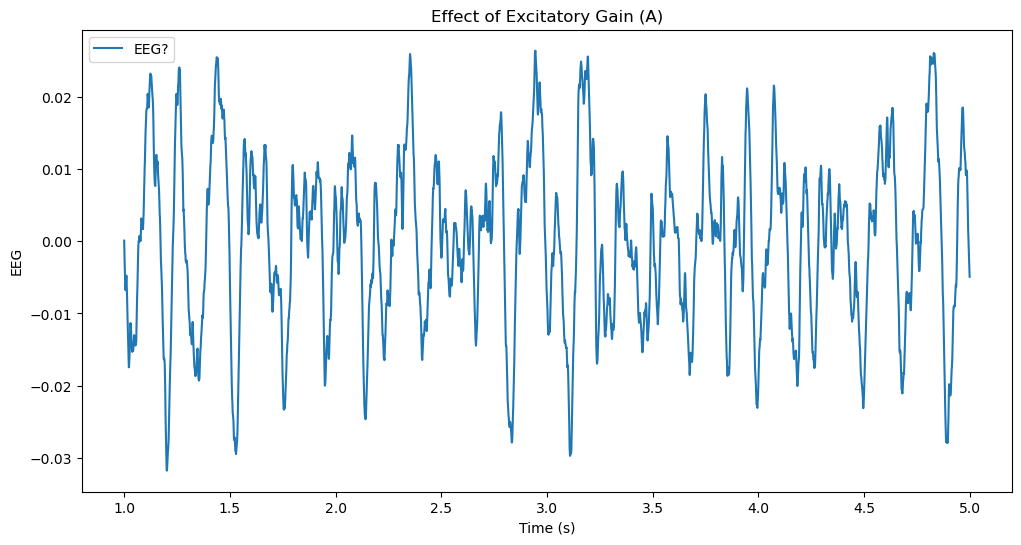

In [33]:
A=6
B = 22
a = 50; b = 25
C2 = 108; C4 = 33.75
p = 140 + 1*np.random.randn(N)
a = a*1.5
b= b*1.5

plt.figure(figsize=(12,6))


t2, EEG = simulate(A, B, a, b, C2, C4, p)
plt.plot(t2, EEG, label="EEG?")

plt.legend()
plt.title("Effect of Excitatory Gain (A)")
plt.xlabel("Time (s)")
plt.ylabel("EEG")
plt.show()

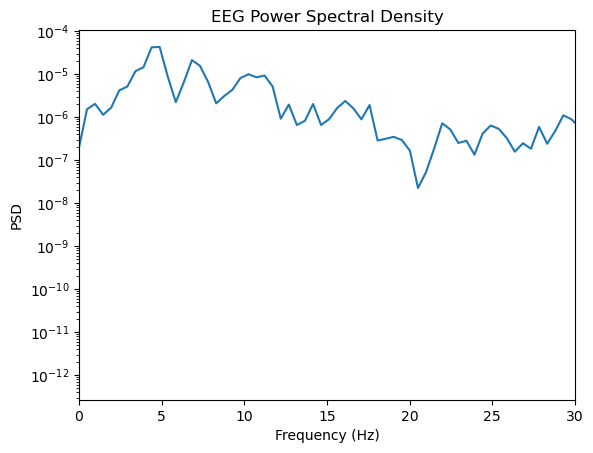

In [34]:
freqs, psd = welch(
        EEG,
        fs=fs,
        nperseg=2048
    )

plt.semilogy(freqs, psd)

plt.xlim(0, 30)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("EEG Power Spectral Density")
plt.show()

In [22]:
peak_idx = np.argmax(psd[(freqs > 1) & (freqs < 15)])
peak_freq = freqs[(freqs > 1) & (freqs < 15)][peak_idx]
print("Peak frequency:", peak_freq)

Peak frequency: 5.859375


increase in a,b  → freqency ↑, stability ↓

As expected

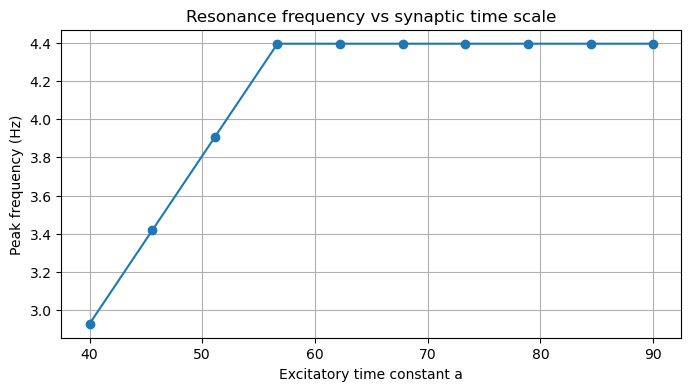

In [23]:
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt


A = 6
B = 22
C2 = 108
C4 = 33.75
p = 140 + 1*np.random.randn(N)
fs = 1 / dt

a_vals = np.linspace(40, 90, 10)
peak_freqs = []


for a in a_vals:
    b = a / 2

    t2, EEG = simulate(A, B, a, b, C2, C4, p)

    freqs, psd = welch(
        EEG,
        fs=fs,
        nperseg=2048
    )

    
    mask = (freqs > 1) & (freqs < 20)
    peak_f = freqs[mask][np.argmax(psd[mask])]
    peak_freqs.append(peak_f)


plt.figure(figsize=(8,4))
plt.plot(a_vals, peak_freqs, marker="o")
plt.xlabel("Excitatory time constant a")
plt.ylabel("Peak frequency (Hz)")
plt.title("Resonance frequency vs synaptic time scale")
plt.grid(True)
plt.show()


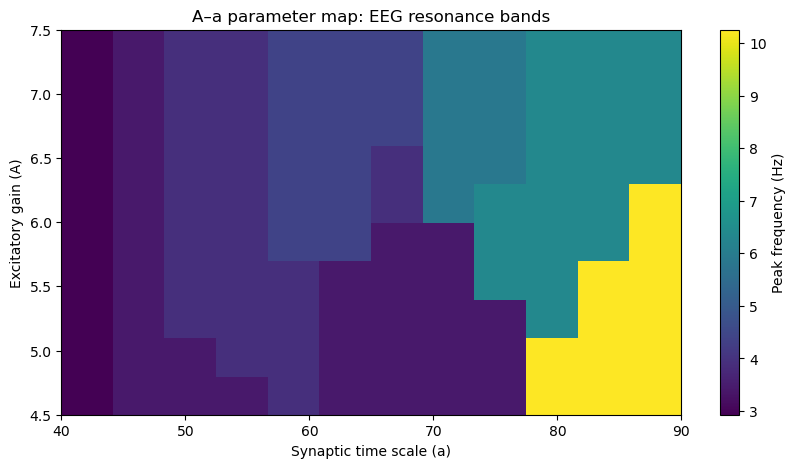

In [24]:
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt


B = 22
C2 = 108
C4 = 33.75
fs = 1 / dt

p = 140 + 1*np.random.randn(N)


A_vals = np.linspace(4.5, 7.5, 10)
a_vals = np.linspace(40, 90, 12)

peak_map = np.zeros((len(A_vals), len(a_vals)))


for i, A in enumerate(A_vals):
    for j, a in enumerate(a_vals):
        b = a / 2

        t2, EEG = simulate(A, B, a, b, C2, C4, p)

        freqs, psd = welch(
            EEG,
            fs=fs,
            nperseg=2048
        )

        mask = (freqs > 1) & (freqs < 20)

        if np.max(psd[mask]) < 1e-6:
            peak_map[i, j] = np.nan  
        else:
            peak_map[i, j] = freqs[mask][np.argmax(psd[mask])]


plt.figure(figsize=(10,5))
im = plt.imshow(
    peak_map,
    origin="lower",
    aspect="auto",
    extent=[a_vals[0], a_vals[-1], A_vals[0], A_vals[-1]],
    cmap="viridis"
)

plt.colorbar(im, label="Peak frequency (Hz)")
plt.xlabel("Synaptic time scale (a)")
plt.ylabel("Excitatory gain (A)")
plt.title("A–a parameter map: EEG resonance bands")
plt.show()


**Why does A look so “weak”?**

Because A’s role is this:

- Putting the system into oscillation  
- Determining the amplitude of the oscillation  

But:  
**Frequency ≠ amplitude**

The mathematical root of the frequency:  
time constants in the differential equations  

That is:  
- **a, b** → time  
- **A, B** → energy / gain  

You have now proven this distinction with the graph.

** Why is this finding very important?**

Because it answers a classic question in the EEG literature:

“Why do people have different alpha frequencies but highly variable powers (amplitudes)?”

**Answer:**  
- Time scales (synaptic/dendritic) are different → different **frequencies**  
- Gain (excitability, A) is different → different **powers/amplitudes**  
- But **gain does not determine the frequency**

Your parameter map / landscape:  
directly supports this hypothesis.

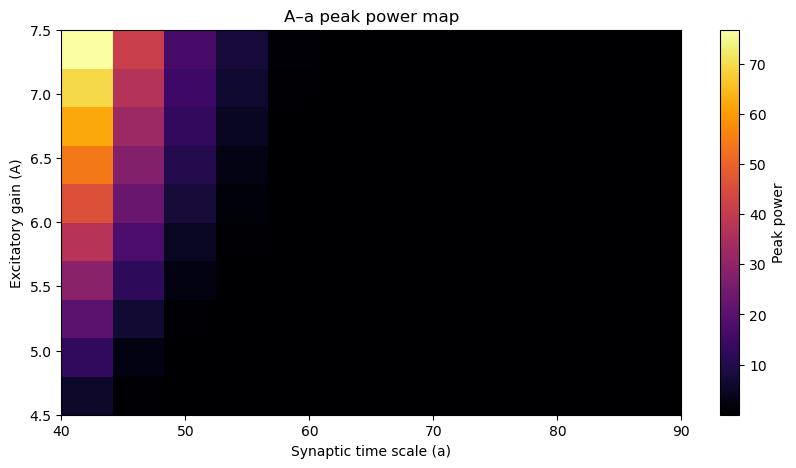

In [25]:
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt


B = 22
C2 = 108
C4 = 33.75
fs = 1 / dt

noise_std = 1.0
p = 140 + noise_std * np.random.randn(N)

A_vals = np.linspace(4.5, 7.5, 10)
a_vals = np.linspace(40, 90, 12)

power_map = np.zeros((len(A_vals), len(a_vals)))


for i, A in enumerate(A_vals):
    for j, a in enumerate(a_vals):
        b = a / 2

        t2, EEG = simulate(A, B, a, b, C2, C4, p)

        freqs, psd = welch(EEG, fs=fs, nperseg=2048)
        mask = (freqs > 1) & (freqs < 20)

        power_map[i, j] = np.max(psd[mask])


plt.figure(figsize=(10,5))
im = plt.imshow(
    power_map,
    origin="lower",
    aspect="auto",
    extent=[a_vals[0], a_vals[-1], A_vals[0], A_vals[-1]],
    cmap="inferno"
)
plt.colorbar(im, label="Peak power")
plt.xlabel("Synaptic time scale (a)")
plt.ylabel("Excitatory gain (A)")
plt.title("A–a peak power map")
plt.show()


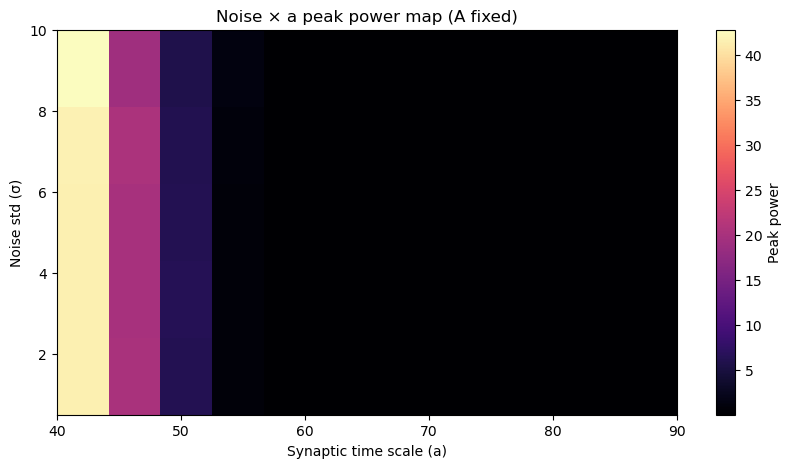

In [26]:
A = 6.0
B = 22
C2 = 108
C4 = 33.75

a_vals = np.linspace(40, 90, 12)
noise_vals = [0.5, 1.0, 2.0, 5.0, 10.0]

noise_power_map = np.zeros((len(noise_vals), len(a_vals)))


for i, noise_std in enumerate(noise_vals):
    p = 140 + noise_std * np.random.randn(N)

    for j, a in enumerate(a_vals):
        b = a / 2

        t2, EEG = simulate(A, B, a, b, C2, C4, p)

        freqs, psd = welch(EEG, fs=fs, nperseg=2048)
        mask = (freqs > 1) & (freqs < 20)

        noise_power_map[i, j] = np.max(psd[mask])


plt.figure(figsize=(10,5))
im = plt.imshow(
    noise_power_map,
    origin="lower",
    aspect="auto",
    extent=[a_vals[0], a_vals[-1], noise_vals[0], noise_vals[-1]],
    cmap="magma"
)
plt.colorbar(im, label="Peak power")
plt.xlabel("Synaptic time scale (a)")
plt.ylabel("Noise std (σ)")
plt.title("Noise × a peak power map (A fixed)")
plt.show()
